# Step 0 Data Preprocessing

In [ ]:
pip install pymongo

from pymongo import MongoClient
from dotenv import load_dotenv
import pandas as pd
import os
import warnings
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


   ---------------------------------------- 0.0/959.2 kB ? eta -:--:--
   --------------------------------------- 959.2/959.2 kB 16.6 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   ---------------------------------------- 2/2 [pymongo]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Connecting to MongoDB and accessing the database and collection
load_dotenv()
CONNECTION_STRING = os.getenv("MONGO_CONNECTION_STRING")

client = MongoClient(CONNECTION_STRING)
db = client["final_project"]
collection = db["savant"]

In [ ]:
# Fetching all documents from the collection and converting to a DataFrame
results = collection.find({})
df = pd.DataFrame(list(results))

df.head()

,_id,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,69d3c54eef428760b51381cf,SL,11/1/2025,85.9,-3.1,5.64,"Scherzer, Max",500743,453286,single,...,,3.13,-0.2,-0.2,31.5,-5.823739,-17.027322,29.582052,32.972714,44.206122
1,69d3c54eef428760b51381d0,SL,11/1/2025,85.4,-3.11,5.55,"Scherzer, Max",500743,453286,,...,,2.86,-0.29,-0.29,33.7,,,,,
2,69d3c54eef428760b51381d1,CH,11/1/2025,84.8,-3.3,5.36,"Scherzer, Max",571771,453286,,...,,2.82,0.79,0.79,27.4,,,,,
3,69d3c54eef428760b51381d2,CU,11/1/2025,73.2,-3.02,5.75,"Scherzer, Max",571771,453286,strikeout,...,,5.25,-1.04,-1.04,40.4,2.410072,30.857094,31.03147,44.98723,21.325831
4,69d3c54eef428760b51381d3,SL,11/1/2025,88.7,-1.92,5.99,"Ohtani, Shohei",666182,660271,home_run,...,,2.64,-0.1,-0.1,40.8,3.753491,-9.95437,31.73651,37.886817,30.395348


In [3]:
df = df.replace("", pd.NA)

In [4]:

for column in df.columns:
    null_percentage = df[column].isna().sum() / len(df) * 100
    
    print(f"Column: {column}, Null Percentage: {null_percentage:.2f}%")

Column: _id, Null Percentage: 0.00%
Column: pitch_type, Null Percentage: 0.67%
Column: game_date, Null Percentage: 0.00%
Column: release_speed, Null Percentage: 0.67%
Column: release_pos_x, Null Percentage: 0.67%
Column: release_pos_z, Null Percentage: 0.67%
Column: player_name, Null Percentage: 0.00%
Column: batter, Null Percentage: 0.00%
Column: pitcher, Null Percentage: 0.00%
Column: events, Null Percentage: 74.59%
Column: description, Null Percentage: 0.00%
Column: spin_dir, Null Percentage: 100.00%
Column: spin_rate_deprecated, Null Percentage: 100.00%
Column: break_angle_deprecated, Null Percentage: 100.00%
Column: break_length_deprecated, Null Percentage: 100.00%
Column: zone, Null Percentage: 0.67%
Column: des, Null Percentage: 0.00%
Column: game_type, Null Percentage: 0.00%
Column: stand, Null Percentage: 0.00%
Column: p_throws, Null Percentage: 0.00%
Column: home_team, Null Percentage: 0.00%
Column: away_team, Null Percentage: 0.00%
Column: type, Null Percentage: 0.00%
Column

In [4]:
# converting on_1b - on_3b to boolean
df['on_1b'] = df['on_1b'].notna().astype(int)
df['on_2b'] = df['on_2b'].notna().astype(int)
df['on_3b'] = df['on_3b'].notna().astype(int)

In [5]:
# Important features
features = [
    # Player context
    "pitcher",
    "p_throws",
    "stand",

    # Count
    "balls",
    "strikes",

    # Game state
    "outs_when_up",
    "inning",
    "inning_topbot",

    # Base runners (binary)
    "on_1b",
    "on_2b",
    "on_3b",

    # Optional context
    "home_score_diff",
    "n_thruorder_pitcher",

    # Potential features
    "release_speed",
    "release_spin_rate",
    "spin_axis"
]

## Phase 1-2: Data Audit, Feature Prep, and Grouped Split

This section:
- Locks the target as `pitch_type`
- Builds a feature set from available pitch physics + existing context features
- Drops rows with missing required fields
- Applies sanity-range filters
- Creates a group-aware train/test split to reduce leakage

In [13]:
TARGET_COL = "pitch_type"

# Existing context features from earlier notebook cell
context_features = [f for f in features if f in df.columns]

# Physics-centric features for real-time pitch classification
physics_candidates = [
    "release_speed",
    "release_spin_rate",
    "spin_axis",
    "pfx_x",
    "pfx_z",
    "vx0",
    "vy0",
    "vz0",
    "ax",
    "ay",
    "az",
    "release_pos_x",
    "release_pos_y",
    "release_pos_z",
    "release_extension",
]
physics_features = [c for c in physics_candidates if c in df.columns]

selected_features = list(dict.fromkeys(physics_features + context_features))

group_cols = [c for c in ["game_pk", "game_id", "pitcher"] if c in df.columns]
required_cols = list(dict.fromkeys([TARGET_COL] + selected_features + group_cols))
missing_required_cols = [c for c in required_cols if c not in df.columns]
if missing_required_cols:
    raise ValueError(f"Missing required columns: {missing_required_cols}")

model_df = df[required_cols].copy()

# Coerce known numeric fields to numeric because Mongo imports may store them as strings.
numeric_expected = [
    "release_speed",
    "release_spin_rate",
    "spin_axis",
    "pfx_x",
    "pfx_z",
    "vx0",
    "vy0",
    "vz0",
    "ax",
    "ay",
    "az",
    "release_pos_x",
    "release_pos_y",
    "release_pos_z",
    "release_extension",
    "balls",
    "strikes",
    "outs_when_up",
    "inning",
    "on_1b",
    "on_2b",
    "on_3b",
    "home_score_diff",
    "n_thruorder_pitcher",
]
for c in numeric_expected:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.dropna(subset=[TARGET_COL] + selected_features)

# Physics sanity checks to remove impossible values
if "release_speed" in model_df.columns:
    model_df = model_df[(model_df["release_speed"] >= 40) & (model_df["release_speed"] <= 110)]
if "release_spin_rate" in model_df.columns:
    model_df = model_df[(model_df["release_spin_rate"] >= 500) & (model_df["release_spin_rate"] <= 4000)]
if "spin_axis" in model_df.columns:
    model_df = model_df[(model_df["spin_axis"] >= 0) & (model_df["spin_axis"] <= 360)]

model_df = model_df.drop_duplicates().reset_index(drop=True)

print(f"Rows after prep: {len(model_df):,}")
print(f"Target classes: {model_df[TARGET_COL].nunique()}")
print(model_df[TARGET_COL].value_counts().head(15))

Rows after prep: 24,804
Target classes: 10
pitch_type
FF    8276
SL    3875
SI    3538
CH    2301
CU    1780
ST    1534
FC    1460
FS    1324
KC     584
SV     132
Name: count, dtype: int64


In [ ]:
X = model_df[selected_features].copy()
y_raw = model_df[TARGET_COL].astype(str).copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in selected_features if c not in cat_cols]

# Grouped split to reduce leakage. Prefer game-level grouping, otherwise pitcher-level.
if "game_pk" in model_df.columns:
    group_key = model_df["game_pk"].astype(str)
elif "game_id" in model_df.columns:
    group_key = model_df["game_id"].astype(str)
elif "pitcher" in model_df.columns:
    group_key = model_df["pitcher"].astype(str)
else:
    group_key = None

all_idx = np.arange(len(X))
if group_key is not None:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=group_key))
else:
    print("No group column available. Falling back to stratified random split.")
    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Categorical cols: {len(cat_cols)} and Numeric cols: {len(num_cols)}")

Train rows: 19,674
Test rows: 5,130
Categorical cols: 3 | Numeric cols: 25


## Phase 3: Train RF, CatBoost, and XGBoost

In [ ]:
models = {}
preds = {}
probas = {}

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# Baseline sanity floor (Always predict most common class FF)
baseline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]
)
baseline.fit(X_train, y_train)
models["Baseline"] = baseline
preds["Baseline"] = baseline.predict(X_test)

# Random Forest
rf = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)
rf.fit(X_train, y_train)
models["RandomForest"] = rf
preds["RandomForest"] = rf.predict(X_test)
if hasattr(rf.named_steps["clf"], "predict_proba"):
    probas["RandomForest"] = rf.predict_proba(X_test)

# CatBoost with native categorical handling
catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=500,
    learning_rate=0.05,
    depth=8,
    eval_metric="TotalF1:average=Macro",
    random_seed=42,
    verbose=False,
)
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_cols]
catboost_model.fit(X_train, y_train, cat_features=cat_feature_indices)
models["CatBoost"] = catboost_model
preds["CatBoost"] = catboost_model.predict(X_test).reshape(-1).astype(int)
probas["CatBoost"] = catboost_model.predict_proba(X_test)

# XGBoost
xgb = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "clf",
            XGBClassifier(
                objective="multi:softprob",
                num_class=len(label_encoder.classes_),
                eval_metric="mlogloss",
                n_estimators=350,
                max_depth=8,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
xgb.fit(X_train, y_train)
models["XGBoost"] = xgb
preds["XGBoost"] = xgb.predict(X_test)
if hasattr(xgb.named_steps["clf"], "predict_proba"):
    probas["XGBoost"] = xgb.predict_proba(X_test)

print(f"Trained models: {list(models.keys())}")

Trained models: ['Baseline', 'RandomForest', 'CatBoost', 'XGBoost']


## Phase 4: Evaluation and Comparison

In [16]:
def evaluate_model(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = [evaluate_model(y_test, y_hat, name) for name, y_hat in preds.items()]
results_df = pd.DataFrame(results).sort_values(["macro_f1", "weighted_f1"], ascending=False)
results_df

,model,accuracy,macro_f1,weighted_f1
3,XGBoost,0.894542,0.796441,0.893282
2,CatBoost,0.885575,0.776208,0.883833
1,RandomForest,0.886550,0.759101,0.882976
0,Baseline,0.332359,0.049890,0.165815



=== Baseline ===
              precision    recall  f1-score   support

          CH       0.00      0.00      0.00       570
          CU       0.00      0.00      0.00       351
          FC       0.00      0.00      0.00       297
          FF       0.33      1.00      0.50      1705
          FS       0.00      0.00      0.00       230
          KC       0.00      0.00      0.00       105
          SI       0.00      0.00      0.00       804
          SL       0.00      0.00      0.00       689
          ST       0.00      0.00      0.00       355
          SV       0.00      0.00      0.00        24

    accuracy                           0.33      5130
   macro avg       0.03      0.10      0.05      5130
weighted avg       0.11      0.33      0.17      5130



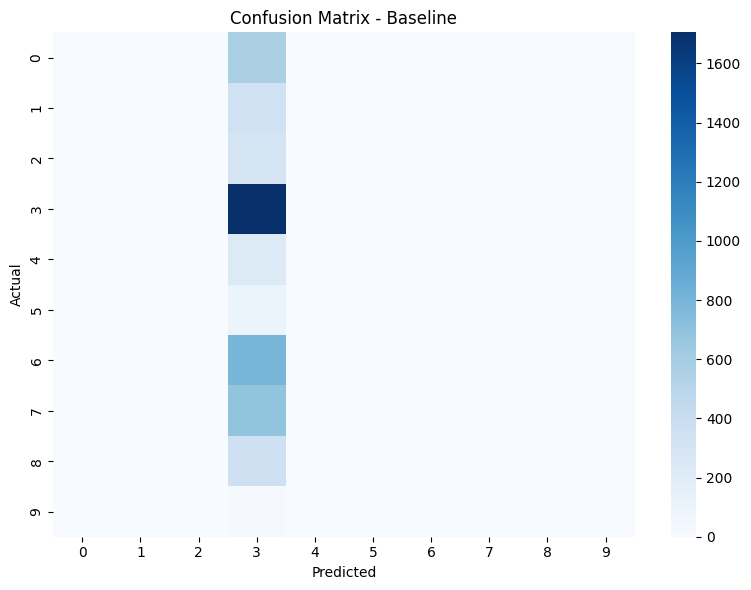


=== RandomForest ===
              precision    recall  f1-score   support

          CH       0.87      0.90      0.89       570
          CU       0.82      0.94      0.88       351
          FC       0.80      0.56      0.66       297
          FF       0.97      0.97      0.97      1705
          FS       0.81      0.92      0.86       230
          KC       0.92      0.55      0.69       105
          SI       0.96      0.88      0.92       804
          SL       0.76      0.91      0.82       689
          ST       0.85      0.81      0.83       355
          SV       1.00      0.04      0.08        24

    accuracy                           0.89      5130
   macro avg       0.88      0.75      0.76      5130
weighted avg       0.89      0.89      0.88      5130



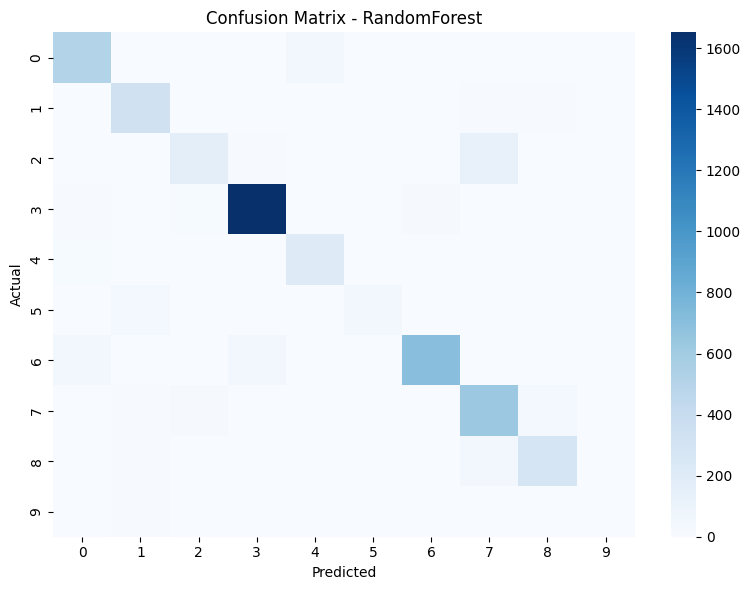


=== CatBoost ===
              precision    recall  f1-score   support

          CH       0.89      0.86      0.87       570
          CU       0.85      0.86      0.85       351
          FC       0.75      0.59      0.66       297
          FF       0.97      0.98      0.97      1705
          FS       0.75      0.93      0.83       230
          KC       0.72      0.67      0.69       105
          SI       0.97      0.89      0.93       804
          SL       0.77      0.90      0.83       689
          ST       0.85      0.82      0.83       355
          SV       1.00      0.17      0.29        24

    accuracy                           0.89      5130
   macro avg       0.85      0.77      0.78      5130
weighted avg       0.89      0.89      0.88      5130



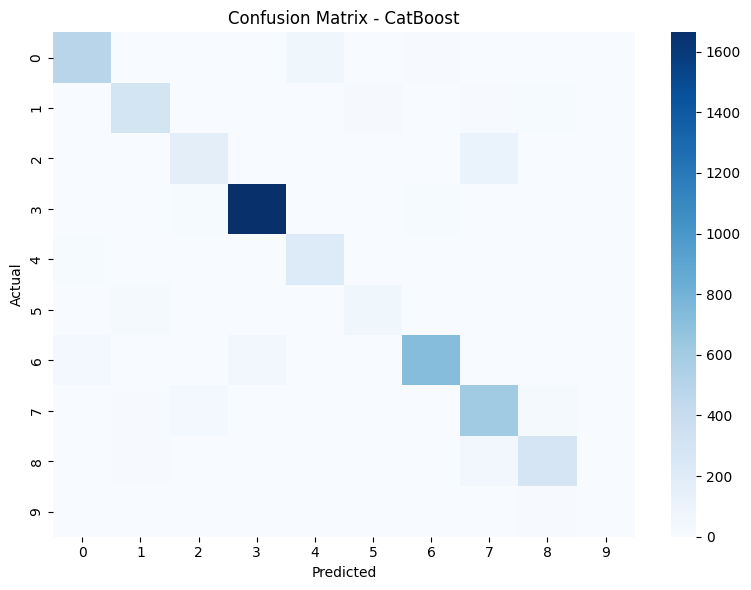


=== XGBoost ===
              precision    recall  f1-score   support

          CH       0.90      0.89      0.89       570
          CU       0.87      0.85      0.86       351
          FC       0.78      0.64      0.70       297
          FF       0.98      0.97      0.97      1705
          FS       0.81      0.96      0.88       230
          KC       0.73      0.69      0.71       105
          SI       0.95      0.91      0.93       804
          SL       0.78      0.90      0.83       689
          ST       0.84      0.84      0.84       355
          SV       1.00      0.21      0.34        24

    accuracy                           0.89      5130
   macro avg       0.86      0.78      0.80      5130
weighted avg       0.90      0.89      0.89      5130



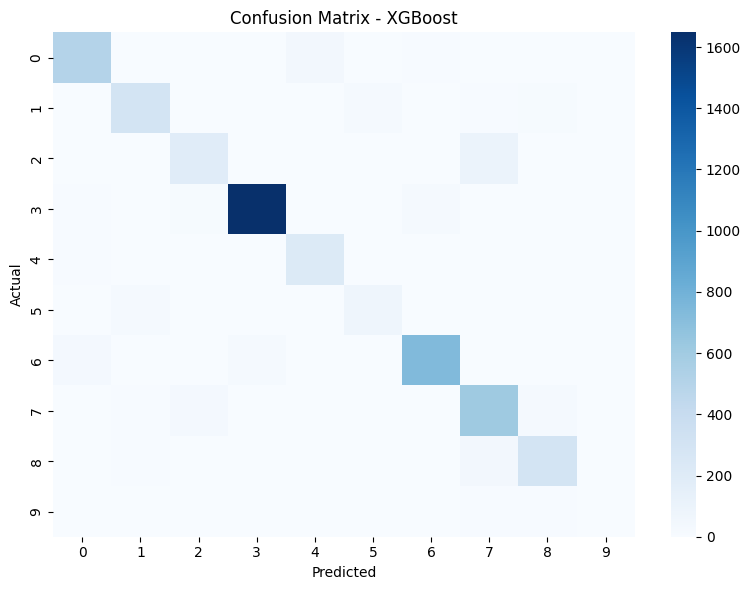

In [17]:
class_names = list(label_encoder.classes_)

for model_name, y_hat in preds.items():
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_hat, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [18]:
# Feature importance snapshots
if "RandomForest" in models:
    rf_model = models["RandomForest"]
    ohe = rf_model.named_steps["prep"].named_transformers_["cat"]
    rf_feature_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
    rf_importances = pd.Series(
        rf_model.named_steps["clf"].feature_importances_,
        index=rf_feature_names,
    ).sort_values(ascending=False)
    display(rf_importances.head(20).to_frame("rf_importance"))

if "XGBoost" in models:
    xgb_model = models["XGBoost"]
    xgb_ohe = xgb_model.named_steps["prep"].named_transformers_["cat"]
    xgb_feature_names = list(xgb_ohe.get_feature_names_out(cat_cols)) + num_cols
    xgb_importances = pd.Series(
        xgb_model.named_steps["clf"].feature_importances_,
        index=xgb_feature_names,
    ).sort_values(ascending=False)
    display(xgb_importances.head(20).to_frame("xgb_importance"))

if "CatBoost" in models:
    cb_importances = pd.Series(
        models["CatBoost"].get_feature_importance(),
        index=selected_features,
    ).sort_values(ascending=False)
    display(cb_importances.head(20).to_frame("catboost_importance"))

,rf_importance
release_spin_rate,0.094836
pfx_z,0.090517
az,0.086922
ax,0.081389
pfx_x,0.077576
spin_axis,0.072690
vy0,0.069519
release_speed,0.064569
pitcher,0.057030
release_pos_z,0.051084


,xgb_importance
p_throws_R,0.184505
pfx_z,0.167489
az,0.098340
ax,0.074942
release_spin_rate,0.072353
p_throws_L,0.066403
release_speed,0.060023
vy0,0.045649
pfx_x,0.032513
spin_axis,0.031512


,catboost_importance
pfx_x,11.723313
pfx_z,10.036666
pitcher,9.169172
release_spin_rate,8.797553
release_pos_x,7.352548
release_pos_z,6.810662
spin_axis,6.597369
az,6.351013
vy0,6.323679
ax,6.278616


## Phase 5: Hyperparameter Tuning (After Baselines)

Set `RUN_TUNING = True` only when you want to run the search. This can take several minutes. Not necessary as the results are already very good

In [ ]:
RUN_TUNING = False

if RUN_TUNING:
    from sklearn.model_selection import RandomizedSearchCV

    tuned = {}

    if "RandomForest" in models:
        rf_search = RandomizedSearchCV(
            estimator=models["RandomForest"],
            param_distributions={
                "clf__n_estimators": [300, 500, 700],
                "clf__max_depth": [None, 10, 16, 24],
                "clf__min_samples_split": [2, 5, 10],
                "clf__min_samples_leaf": [1, 2, 4],
            },
            n_iter=12,
            cv=3,
            scoring="f1_macro",
            n_jobs=-1,
            random_state=42,
            verbose=1,
        )
        rf_search.fit(X_train, y_train)
        tuned["RandomForest"] = rf_search.best_estimator_
        print("RF best params:", rf_search.best_params_)

    if "XGBoost" in models:
        xgb_search = RandomizedSearchCV(
            estimator=models["XGBoost"],
            param_distributions={
                "clf__n_estimators": [300, 500, 700],
                "clf__max_depth": [6, 8, 10],
                "clf__learning_rate": [0.03, 0.05, 0.08],
                "clf__subsample": [0.8, 0.9, 1.0],
                "clf__colsample_bytree": [0.8, 0.9, 1.0],
            },
            n_iter=12,
            cv=3,
            scoring="f1_macro",
            n_jobs=-1,
            random_state=42,
            verbose=1,
        )
        xgb_search.fit(X_train, y_train)
        tuned["XGBoost"] = xgb_search.best_estimator_
        print("XGB best params:", xgb_search.best_params_)

    if tuned:
        tuned_results = []
        for name, tuned_model in tuned.items():
            tuned_pred = tuned_model.predict(X_test)
            tuned_results.append(evaluate_model(y_test, tuned_pred, f"{name}_Tuned"))
        display(pd.DataFrame(tuned_results).sort_values("macro_f1", ascending=False))
else:
    print("Tuning skipped. Set RUN_TUNING = True to enable.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
RF best params: {'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': 16}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
XGB best params: {'clf__subsample': 0.8, 'clf__n_estimators': 700, 'clf__max_depth': 10, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.8}


,model,accuracy,macro_f1,weighted_f1
1,XGBoost_Tuned,0.894737,0.795024,0.893335
0,RandomForest_Tuned,0.879532,0.772871,0.878471


## Phase 6: Reporting and Inference Helper

In [ ]:
print("Modeling summary")
print("Target:", TARGET_COL)
print("Selected features:", len(selected_features))
print("Split strategy:", "GroupShuffleSplit by game/pitcher when available")
print("Baseline models requested:", "RandomForest + CatBoost + XGBoost")

best_model_name = results_df.iloc[0]["model"]
print("Best baseline model by macro_f1:", best_model_name)


def predict_top_k(pitch_row: dict, model_name: str = None, top_k: int = 3):
    """Return top-k predicted pitch types with probabilities for a single pitch row."""
    if model_name is None:
        model_name = results_df.iloc[0]["model"]

    if model_name not in models:
        raise ValueError(f"Model '{model_name}' is not available. Choose from {list(models.keys())}")

    row_df = pd.DataFrame([pitch_row])
    for col in selected_features:
        if col not in row_df.columns:
            row_df[col] = np.nan
    row_df = row_df[selected_features]

    model = models[model_name]

    # Ensure categoricals are strings for CatBoost
    for c in cat_cols:
        if c in row_df.columns:
            row_df[c] = row_df[c].astype(str)

    if model_name == "CatBoost":
        probs = model.predict_proba(row_df)[0]
    else:
        if not hasattr(model, "predict_proba"):
            raise ValueError(f"Model '{model_name}' does not support predict_proba")
        probs = model.predict_proba(row_df)[0]

    order = np.argsort(probs)[::-1][:top_k]
    labels = label_encoder.inverse_transform(order)
    return pd.DataFrame({"pitch_type": labels, "probability": probs[order]})

# Example usage:
# sample_input = X_test.iloc[0].to_dict()
# predict_top_k(sample_input, model_name=best_model_name, top_k=3)

Modeling summary
- Target: pitch_type
- Selected features: 28
- Split strategy: GroupShuffleSplit by game/pitcher when available
- Baseline models requested: RandomForest + CatBoost + XGBoost
- Best baseline model by macro_f1: XGBoost
